In [1]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from collections import defaultdict
from scipy.stats import norm as norm_dist
from networkx import fast_gnp_random_graph


import netbiol3 as nb
from netective import struct

import warnings
warnings.filterwarnings("ignore")


a = nb.Abasy()

In [23]:
def compute_correlation(props1, props2):
    r, pval = pearsonr(np.fromiter(props1.values(), dtype=float), np.fromiter(props2.values(), dtype=float))
    # print(f'pval: {pval}')
    return r

def cv(vals):
    """Coefficient of variation"""
    return np.std(vals)/np.mean(vals)

def corr_diff_test(r1, r2, n1, n2):
    """Test the difference between two correlation coefficients.
    
    REfs: https://github.com/psinger/CorrelationStats/blob/master/corrstats.py
    
    may be useful later: https://www.tandfonline.com/doi/abs/10.1080/00221309809595548
        they show that is better to use the avg of Fisher transformations, then transform back to Pearson"""
    z1 = 0.5 * math.log((1 + r1) / (1 - r1))
    z2 = 0.5 * math.log((1 + r2) / (1 - r2))
    se = math.sqrt(1 / (n1 - 3) + 1 / (n2 - 3))
    z = (z1 - z2) / se
    p = 2 * (1 - norm_dist.cdf(abs(z))) # two-tailed
    return p

def props_tester(regnetid, norm, erdos_renyi):
    # biological network to use as a reference
    biol = a.regnet(regnetid)
    _, biol_struct = struct.struc_props(biol, 'coli', norm=True)

    pearson_i = []
    props_er = defaultdict(list)
    n = biol.number_of_nodes()
    m = biol.number_of_edges()

    for i in range(erdos_renyi):

        # generate random graph & compute its properties
        ER = nb.RegNet(fast_gnp_random_graph(n, m/(n**2), directed=True))
        _, props_i = struct.struc_props(ER, f'ER_{i}', norm)

        # save ER properties
        for k, v in props_i.items():
            props_er[k].append(v)
        
        # compute correlation between ER and biological network
        pearson_i.append(compute_correlation(biol_struct, props_i))

    props_er_avg = {prop: sum(vals)/len(vals) for prop, vals in props_er.items()}
    er_av_biol = compute_correlation(biol_struct, props_er_avg)
    r_avg = np.mean(pearson_i)
    cov_r_avg = cv(pearson_i)


    diff_pval = corr_diff_test(r_avg, er_av_biol, len(biol_struct), len(biol_struct))

    return cov_r_avg, r_avg, er_av_biol, diff_pval

def plot_scatter(x, df):
    fig, axes = plt.subplots(2, 2, figsize=(7,7))
    axes = axes.flatten()

    for i, col in enumerate(['cov_r_avg', 'r_avg', 'er_av_biol', 'diff_pval']):
        sns.scatterplot(x=x, y=col, data=df, ax=axes[i])
        axes[i].set_title(col)

    # add xtickvalues each 500 nodes
    xticks = np.arange(0, max(df[x]), 500)
    for ax in axes:
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticks, rotation=90)

    plt.tight_layout()
    plt.show()


In [4]:
norm = True
erdos_renyi = 100
values = []

all_regnets = a.select_regnets(nr_strong_wa=True)
counter = 0
for regnetid in all_regnets:
    cov_r_avg, r_avg, er_av_biol, diff_pval = props_tester(regnetid, norm, erdos_renyi)
    G = a.regnet(regnetid)
    nodes = G.number_of_nodes()
    edges = G.number_of_edges()
    values.append((regnetid, nodes, edges, cov_r_avg, r_avg, er_av_biol, diff_pval))

    counter += 1
    print(f'{counter}/{len(all_regnets)}', flush=True)
    

regnetid, nodes, edges, cov_r_avg, r_avg, er_av_biol, diff_pval = zip(*values)
df = pd.DataFrame({'regnetid': regnetid, 'nodes': nodes, 'edges': edges, 'cov_r_avg': cov_r_avg, 'r_avg': r_avg, 'er_av_biol': er_av_biol, 'diff_pval': diff_pval})

1/42
2/42
3/42
4/42
5/42
6/42
7/42
8/42
9/42
10/42
11/42
12/42
13/42
14/42
15/42
16/42
17/42
18/42
19/42
20/42
21/42
22/42
23/42
24/42
25/42
26/42
27/42
28/42
29/42
30/42
31/42
32/42
33/42
34/42
35/42
36/42
37/42
38/42
39/42
40/42
41/42
42/42


In [5]:
df[:2]

,regnetid,nodes,edges,cov_r_avg,r_avg,er_av_biol,diff_pval
0,451516_v2015_sRTB13,683,2018,0.076871,0.564703,0.569322,0.987853
1,331111_v2015_sRTB13,296,439,0.188691,0.628870,0.652469,0.928657


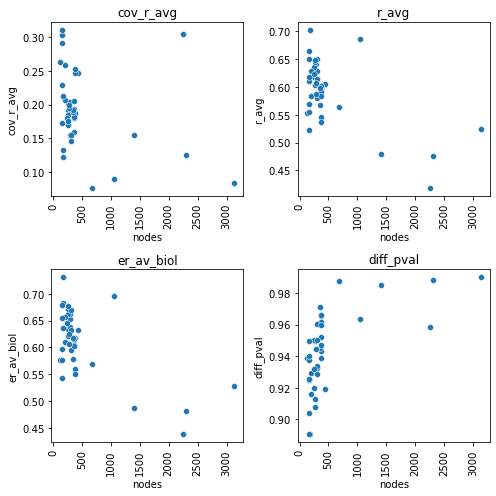

In [27]:
plot_scatter('nodes', df)


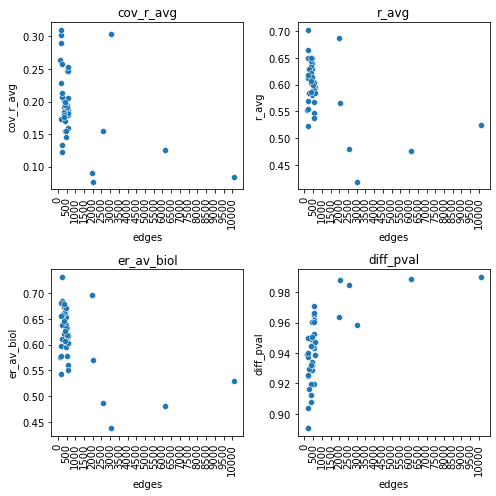

In [24]:
plot_scatter('edges', df)

In [29]:
# kolmogorov-smirnov test for r_avg vs er_av_biol

from scipy.stats import ks_2samp
ks_2samp(df['r_avg'], df['er_av_biol'])


KstestResult(statistic=0.23809523809523808, pvalue=0.18591123196662132)

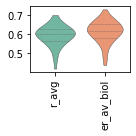

In [30]:
# vertical violinplots for r_avg vs er_av_biol columns, same ax

fig, ax = plt.subplots(figsize=(2, 2))
sns.violinplot(data=df[['r_avg', 'er_av_biol']], ax=ax, orient='v', cut=0, inner='quartile', linewidth=0.5, palette='Set2')
ax.set_xticklabels(['r_avg', 'er_av_biol'], rotation=90)
plt.tight_layout()